In [ ]:
# QSVM via Qiskit (replacement for your Classiq workflow)
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from qiskit import QuantumCircuit
from qiskit.providers.aer import AerSimulator
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


C:\Users\samsung\AppData\Local\Temp\ipykernel_11436\4202212742.py:7: DeprecationWarning: Importing from 'qiskit.providers.aer' is deprecated. Import from 'qiskit_aer' instead, which should work identically.
  from qiskit.providers.aer import AerSimulator


In [ ]:
# 1) Data generation (replacement for classiq.generate_data)
def generate_data(sources, n_per_source=20, scale=0.3, random_state=0):
    """
    sources: array-like shape (num_classes, feature_dim)
    returns dict: {class_label: np.array([...])}
    """
    rng = np.random.default_rng(random_state)
    data = {}
    for k, center in enumerate(sources):
        pts = rng.normal(loc=center, scale=scale, size=(n_per_source, len(center)))
        data[k] = pts
    return data

def data_dict_to_data_and_labels(d):
    X_list = []
    y_list = []
    for k in sorted(d.keys()):
        pts = np.asarray(d[k])
        X_list.append(pts)
        y_list += [k] * len(pts)
    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y


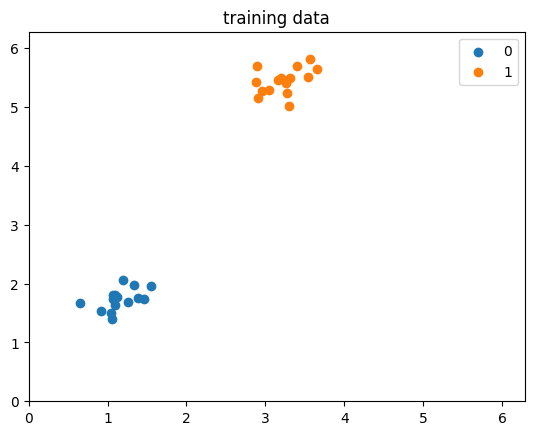

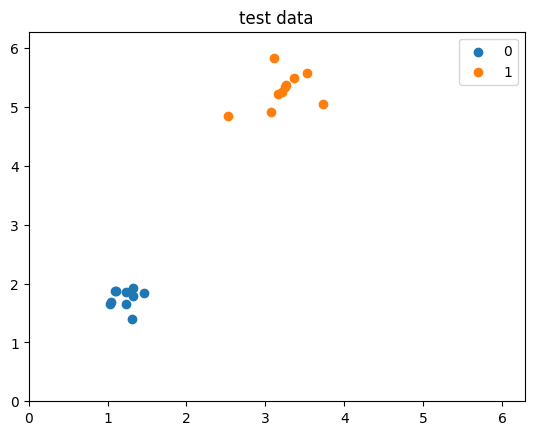

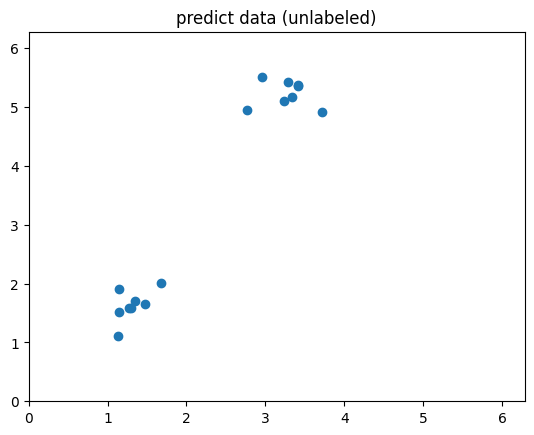

In [ ]:
# 2) prepare data (same sources as your Classiq example)
np.random.seed(0)
sources = np.array([[1.23016026, 1.72327701], [3.20331931, 5.32365722]])

training_input = generate_data(sources=sources, n_per_source=15, scale=0.25, random_state=0)
test_input     = generate_data(sources=sources, n_per_source=10, scale=0.25, random_state=1)
predict_dict   = generate_data(sources=sources, n_per_source=8,  scale=0.25, random_state=2)

TRAIN_DATA, TRAIN_LABEL = data_dict_to_data_and_labels(training_input)
TEST_DATA,  TEST_LABEL  = data_dict_to_data_and_labels(test_input)
PREDICT_DATA, PREDICT_LABELS = data_dict_to_data_and_labels(predict_dict)  # keep real labels for eval

# Plotting (same look as you had)
plot_range = (0, 2 * np.pi)
for k, v in training_input.items():
    plt.scatter(*v.T, label=str(k))
plt.legend(); plt.title("training data"); plt.xlim(plot_range); plt.ylim(plot_range); plt.show()

for k, v in test_input.items():
    plt.scatter(*v.T, label=str(k))
plt.legend(); plt.title("test data"); plt.xlim(plot_range); plt.ylim(plot_range); plt.show()

plt.scatter(*PREDICT_DATA.T)
plt.title("predict data (unlabeled)")
plt.xlim(plot_range); plt.ylim(plot_range); plt.show()


In [ ]:
# 3) Feature-map (Bloch / dense-angle encoding)
#    maps a d-dim vector -> ceil(d/2) qubits using:
#       RX(x[2*i]/2); RZ(x[2*i+1]) (if exists)
# ----------------------------
def bloch_feature_map_circuit(x: np.ndarray):
    """Return a QuantumCircuit that encodes vector x using dense-angle encoding."""
    d = len(x)
    n_qubits = int(ceil(d / 2))
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        idx0 = 2 * i
        if idx0 < d:
            qc.rx(float(x[idx0]) / 2.0, i)
        idx1 = 2 * i + 1
        if idx1 < d:
            qc.rz(float(x[idx1]), i)
    return qc


In [ ]:
# quick test: show circuit for one example
_example_circ = bloch_feature_map_circuit(np.array([1.2, 0.5]))
print(_example_circ.draw(output='text'))


   ┌─────────┐┌─────────┐
q: ┤ Rx(0.6) ├┤ Rz(0.5) ├
   └─────────┘└─────────┘


In [ ]:
# 4) Build kernel circuits: for pair (x1, x2) we create U(x1) + U(x2)^\dagger + measure
#    measuring all zeros probability = |<phi(x2)|phi(x1)>|^2
def make_kernel_circuit(x1, x2):
    qc1 = bloch_feature_map_circuit(x1)
    qc2 = bloch_feature_map_circuit(x2)
    n = qc1.num_qubits
    qc = QuantumCircuit(n, n)
    qc.compose(qc1, inplace=True)
    qc.compose(qc2.inverse(), inplace=True)
    qc.measure(range(n), range(n))
    return qc


In [ ]:
# 5) helper to create the paired index list (train: upper triangular only; predict: full)

def get_pairs_for_train(n):
    pairs = []
    for k in range(n):
        for j in range(k, n):
            pairs.append((k, j))
    return pairs

def get_pairs_for_predict(n_predict, n_train):
    pairs = []
    for k in range(n_predict):
        for j in range(n_train):
            pairs.append((k, j))
    return pairs


In [ ]:
# 6) Build circuits batch, run on AerSimulator, and construct kernel matrix
def compute_kernel_matrix_from_pairs(dataA, dataB, pairs, shots=1024):
    """
    dataA: array shape (m, d)
    dataB: array shape (n, d)  (for train mode, dataA==dataB and pairs are upper-triangular)
    pairs: list of (i,j) indices specifying which pair to compute
    returns: list of probabilities in same order as pairs
    """
    circuits = []
    for i, j in pairs:
        circuits.append(make_kernel_circuit(dataA[i], dataB[j]))
    sim = AerSimulator()
    job = sim.run(circuits, shots=shots)
    result = job.result()
    probs = []
    for idx in range(len(circuits)):
        counts = result.get_counts(idx)
        n_qubits = circuits[idx].num_qubits
        all_zero_key = "0" * n_qubits
        p00 = counts.get(all_zero_key, 0) / shots
        probs.append(p00)
    return probs

def construct_kernel_matrix_from_probs(probs, matrix_shape, train=True):
    rows, cols = matrix_shape
    K = np.zeros((rows, cols))
    count = 0
    if train:
        for k in range(rows):
            for j in range(k, cols):
                val = probs[count]
                K[k, j] = val
                K[j, k] = val
                count += 1
    else:
        for k in range(rows):
            for j in range(cols):
                K[k, j] = probs[count]
                count += 1
    return K


In [ ]:
# 7) Train SVM using precomputed kernel (train upper-triangular pairs)
shots = 1024

train_size = TRAIN_DATA.shape[0]
pairs_train = get_pairs_for_train(train_size)
probs_train = compute_kernel_matrix_from_pairs(TRAIN_DATA, TRAIN_DATA, pairs_train, shots=shots)
K_train = construct_kernel_matrix_from_probs(probs_train, (train_size, train_size), train=True)

svm = SVC(kernel='precomputed')
svm.fit(K_train, TRAIN_LABEL)


,C,1.0
,kernel,'precomputed'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
# 8) Predict on TEST_DATA
# predict kernel matrix between TEST and TRAIN
pairs_predict = get_pairs_for_predict(TEST_DATA.shape[0], TRAIN_DATA.shape[0])
probs_predict = compute_kernel_matrix_from_pairs(TEST_DATA, TRAIN_DATA, pairs_predict, shots=shots)
K_predict = construct_kernel_matrix_from_probs(probs_predict, (TEST_DATA.shape[0], TRAIN_DATA.shape[0]), train=False)

y_test_pred = svm.predict(K_predict)
test_score = accuracy_score(TEST_LABEL, y_test_pred)
print("Test accuracy:", test_score)
print("Predicted:", y_test_pred)
print("Real:", TEST_LABEL)

Test accuracy: 1.0
Predicted: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Real: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


Predicted for PREDICT_DATA: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]
Actual (held-out): [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]


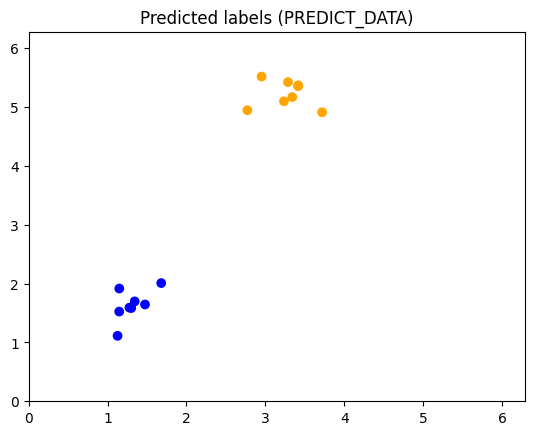

In [ ]:
# 9) Predict new unlabeled PREDICT_DATA
pairs_predict2 = get_pairs_for_predict(PREDICT_DATA.shape[0], TRAIN_DATA.shape[0])
probs_predict2 = compute_kernel_matrix_from_pairs(PREDICT_DATA, TRAIN_DATA, pairs_predict2, shots=shots)
K_predict2 = construct_kernel_matrix_from_probs(probs_predict2, (PREDICT_DATA.shape[0], TRAIN_DATA.shape[0]), train=False)

predicted_labels = svm.predict(K_predict2)
print("Predicted for PREDICT_DATA:", predicted_labels)
print("Actual (held-out):", PREDICT_LABELS)

# Plot predicted labels
COLORS = ["blue", "orange"]
plt.scatter(*PREDICT_DATA.T, color=[COLORS[int(l)] for l in predicted_labels])
plt.title("Predicted labels (PREDICT_DATA)")
plt.xlim(plot_range); plt.ylim(plot_range); plt.show()


In [ ]:
# Quantum SVM on Titanic Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil

# ML imports
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

# Qiskit imports
from qiskit import QuantumCircuit, Aer, execute
from qiskit.utils import QuantumInstance



In [ ]:
# 1) Load & preprocess Titanic dataset
df = pd.read_excel(r"D:\Work\DM\project\titanic3.xls")

# Drop irrelevant columns
df.drop(['fare','name','ticket','cabin','boat','body','home.dest'], axis=1, inplace=True)

# Handle missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Encode categorical
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

le_emb = LabelEncoder()
df['embarked'] = le_emb.fit_transform(df['embarked'])

# Features and labels
X = df[['pclass','sex','age','sibsp','parch','embarked']].values
y = df['survived'].values

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Reduce dataset size (quantum kernel is very slow for full Titanic dataset)
X_train_small = X_train[:80]
y_train_small = y_train[:80]

X_test_small = X_test[:20]
y_test_small = y_test[:20]


C:\Users\samsung\AppData\Local\Temp\ipykernel_1740\2155121899.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\samsung\AppData\Local\Temp\ipykernel_1740\2155121899.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [ ]:
# 2) Feature map (Bloch encoding)
def bloch_feature_map_circuit(x: np.ndarray):
    """Dense-angle encoding: maps d-dim vector -> ceil(d/2) qubits"""
    d = len(x)
    n_qubits = int(ceil(d / 2))
    qc = QuantumCircuit(n_qubits)
    for i in range(n_qubits):
        idx0 = 2 * i
        if idx0 < d:
            qc.rx(float(x[idx0]) / 2.0, i)
        idx1 = 2 * i + 1
        if idx1 < d:
            qc.rz(float(x[idx1]), i)
    return qc


In [ ]:
# 3) Helper: compute quantum kernel matrix
def compute_kernel_matrix(X1, X2, shots=1024):
    """
    Compute kernel matrix between datasets X1, X2
    using fidelity of feature map states.
    """
    n1, n2 = len(X1), len(X2)
    backend = Aer.get_backend("aer_simulator")
    kernel_matrix = np.zeros((n1, n2))

    for i in range(n1):
        for j in range(n2):
            qc = QuantumCircuit(max(ceil(X1.shape[1]/2), ceil(X2.shape[1]/2)))
            # Encode first vector
            qc.compose(bloch_feature_map_circuit(X1[i]), inplace=True)
            qc.compose(bloch_feature_map_circuit(-X2[j]), inplace=True)
            qc.save_statevector()

            result = execute(qc, backend=backend, shots=shots).result()
            state = result.get_statevector()
            prob = np.abs(state[0])**2   # overlap with |0...0>
            kernel_matrix[i, j] = prob
    return kernel_matrix


In [ ]:
# 4) Build kernel matrices
# -------------------------------------
print("Computing training kernel...")
K_train = compute_kernel_matrix(X_train_small, X_train_small)

print("Computing testing kernel...")
K_test = compute_kernel_matrix(X_test_small, X_train_small)


Computing training kernel...


C:\Users\samsung\AppData\Local\Temp\ipykernel_1740\59601537.py:8: DeprecationWarning: The 'qiskit.Aer' entry point is deprecated and will be removed in Qiskit 1.0. You should use 'qiskit_aer.Aer' directly instead.
  backend = Aer.get_backend("aer_simulator")
C:\Users\samsung\AppData\Local\Temp\ipykernel_1740\59601537.py:19: DeprecationWarning: The function ``qiskit.execute_function.execute()`` is deprecated as of qiskit 0.46.0. It will be removed in the Qiskit 1.0 release. This function combines ``transpile`` and ``backend.run``, which is covered by ``Sampler`` :mod:`~qiskit.primitives`. Alternatively, you can also run :func:`.transpile` followed by ``backend.run()``.
  result = execute(qc, backend=backend, shots=shots).result()


Computing testing kernel...


In [ ]:
# 5) Train QSVM (SVC with precomputed kernel)
svm = SVC(kernel="precomputed")
svm.fit(K_train, y_train_small)
y_pred = svm.predict(K_test)


In [ ]:
# 6) Evaluate (only on small test subset)
acc = accuracy_score(y_test_small, y_pred)
print("Test Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test_small, y_pred))


Test Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.92      0.80        13
           1       0.67      0.29      0.40         7

    accuracy                           0.70        20
   macro avg       0.69      0.60      0.60        20
weighted avg       0.69      0.70      0.66        20

